In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')


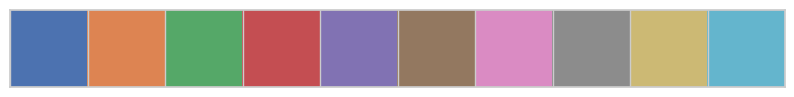

In [3]:
current_palette = sns.color_palette()
sns.palplot(current_palette)
sns.set_style('whitegrid')
sns.set_palette('pastel')
sns.set(color_codes=True)


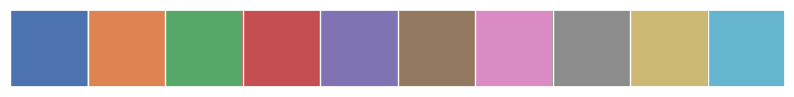

In [4]:
current_palette = sns.color_palette()
sns.palplot(current_palette)
sns.set_style('whitegrid')
sns.set_palette('pastel')
sns.set(color_codes=True)


In [5]:
df = pd.read_csv('air_quality_historical.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

numeric_cols = ['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone','aerosol_optical_depth','dust','uv_index','us_aqi','european_aqi']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['pm10','pm2_5','us_aqi','european_aqi'], how='any')
print('Rows after cleaning:', df.shape[0])
print('Columns:', list(df.columns))
df.head()

Rows after cleaning: 1294
Columns: ['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'us_aqi', 'european_aqi']


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
4,2022-08-05,28.108333,17.554167,428.583333,4.633333,2.100000,63.083333,0.277917,1.000000,1.858333,60.217391,33.521739
5,2022-08-06,28.562500,17.995833,422.291667,4.441667,1.979167,62.208333,0.370833,1.000000,1.577083,62.416667,35.625000
6,2022-08-07,29.100000,18.291667,394.666667,4.487500,1.791667,54.833333,0.349583,0.333333,1.664583,63.583333,36.791667
7,2022-08-08,29.841667,18.662500,364.916667,4.137500,1.654167,54.166667,0.393333,0.458333,1.375000,62.375000,35.583333
8,2022-08-09,36.433333,23.187500,402.583333,4.391667,1.995833,62.333333,0.522083,1.083333,1.122917,68.500000,43.250000


In [7]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

date                     0
pm10                     0
pm2_5                    0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aerosol_optical_depth    0
dust                     0
uv_index                 0
us_aqi                   0
european_aqi             0
dtype: int64

In [11]:
# Descriptive statistics for stakeholder reporting
summary = df[['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone','aerosol_optical_depth','dust','uv_index','us_aqi','european_aqi']].describe().T
summary[['mean','std','min','max']]


,mean,std,min,max
pm10,44.352463,41.368871,1.087500,434.929167
pm2_5,25.939265,21.415995,0.762500,198.166667
carbon_monoxide,550.877447,294.471829,59.708333,2474.458333
nitrogen_dioxide,9.451803,4.060221,0.000000,37.966667
sulphur_dioxide,1.892340,1.133558,0.250000,12.295833
ozone,62.654882,25.135057,27.708333,192.625000
aerosol_optical_depth,0.483298,0.213276,0.039583,1.677500
dust,22.640070,45.152760,0.000000,550.250000
uv_index,1.555009,0.354681,0.427083,2.722917
us_aqi,76.981299,32.567122,16.083333,307.375000


## Stakeholder-focused air quality analysis

This section summarizes the main air quality patterns, highlights the strongest drivers of AQI, builds a simple regression model, and explores time trends for decision-making.

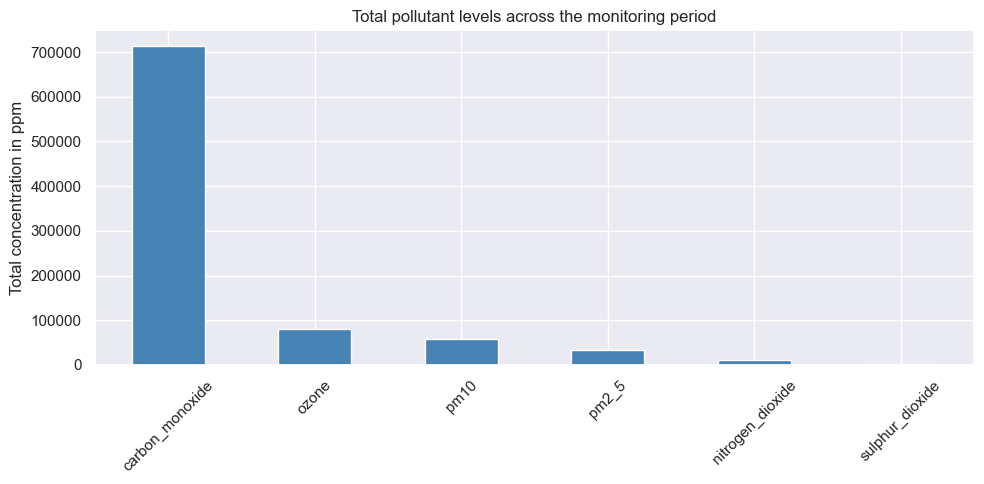

In [8]:
# Bar chart for key pollutant totals
plot_df = df[['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone']].sum().sort_values(ascending=False)
plot_df.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Total pollutant levels across the monitoring period')
plt.ylabel('Total concentration in ppm')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
# Correlation analysis with AQI
corr = df[['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone','aerosol_optical_depth','dust','uv_index','us_aqi','european_aqi']].corr()
correlation_with_aqi = corr['us_aqi'].sort_values(ascending=False)
correlation_with_aqi


us_aqi                   1.000000
european_aqi             0.963008
pm2_5                    0.943761
pm10                     0.906886
ozone                    0.835863
dust                     0.733628
aerosol_optical_depth    0.708903
carbon_monoxide          0.495424
sulphur_dioxide          0.460735
nitrogen_dioxide         0.171619
uv_index                -0.057285
Name: us_aqi, dtype: float64

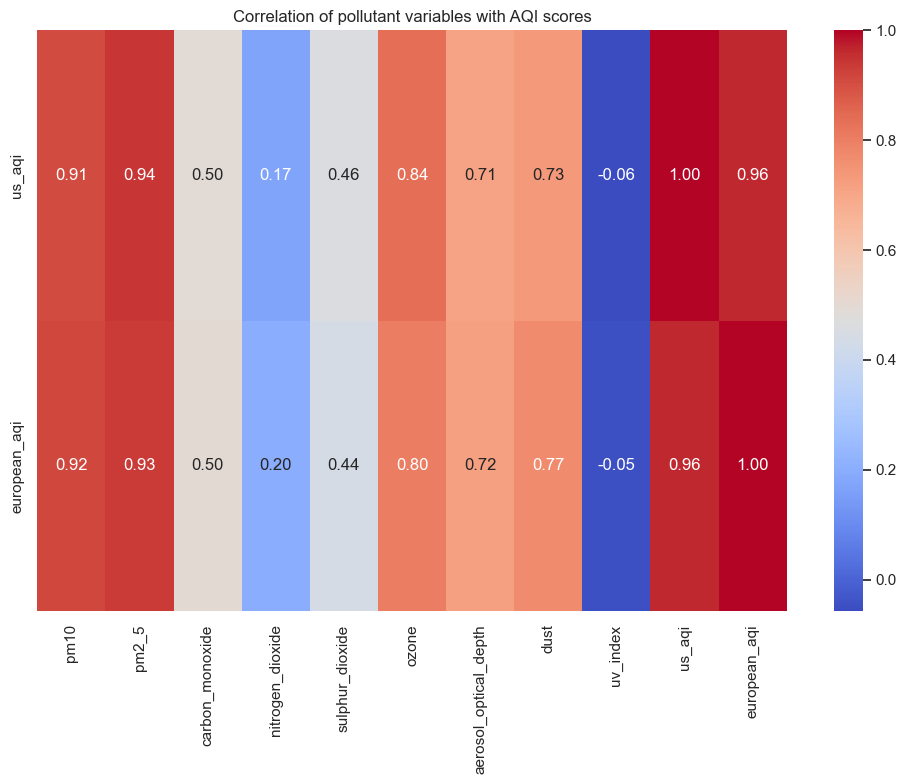

In [14]:
# Heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(corr[['us_aqi','european_aqi']].T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation of pollutant variables with AQI scores')
plt.tight_layout()
plt.show()


In [20]:
# Linear regression: predicting US AQI from key pollutants
from sklearn.linear_model import LinearRegression

features = ['pm10','pm2_5','carbon_monoxide','nitrogen_dioxide','sulphur_dioxide','ozone','aerosol_optical_depth','dust','uv_index']

model_data = df[features + ['us_aqi']].dropna()
X = model_data[features]
y = model_data['us_aqi']

model = LinearRegression()
model.fit(X, y)

regression_summary = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)
regression_summary


,feature,coefficient
6,aerosol_optical_depth,12.984767
8,uv_index,3.977077
0,pm10,0.643731
3,nitrogen_dioxide,0.541934
1,pm2_5,0.431674
5,ozone,0.318655
2,carbon_monoxide,0.003252
7,dust,-0.329169
4,sulphur_dioxide,-2.058703


C:\Users\BMT NETWORKS\AppData\Local\Temp\ipykernel_22608\2762606426.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=regression_summary, x='coefficient', y='feature', palette='viridis')


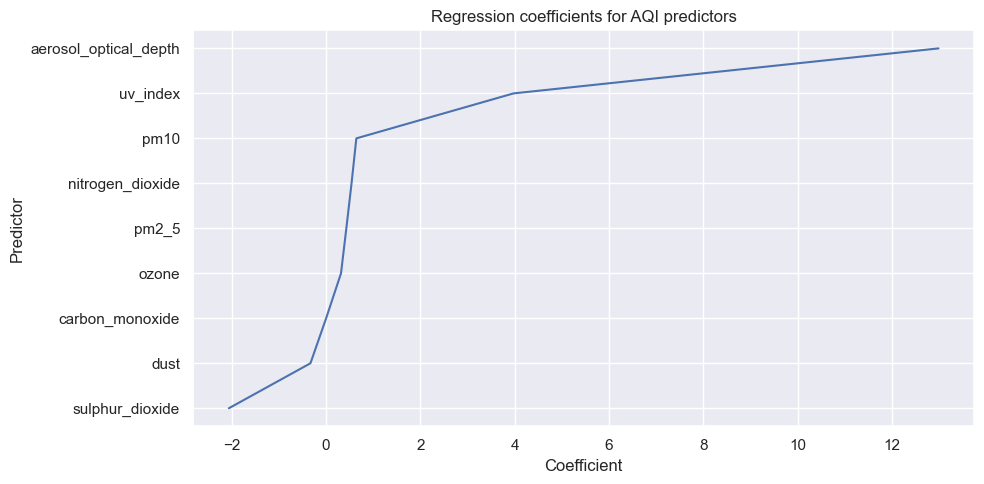

In [22]:
# Plot regression coefficients from the regression summary
plt.figure(figsize=(10, 5))
sns.lineplot(data=regression_summary, x='coefficient', y='feature', palette='viridis')
plt.title('Regression coefficients for AQI predictors')
plt.xlabel('Coefficient')
plt.ylabel('Predictor')
plt.tight_layout()
plt.show()

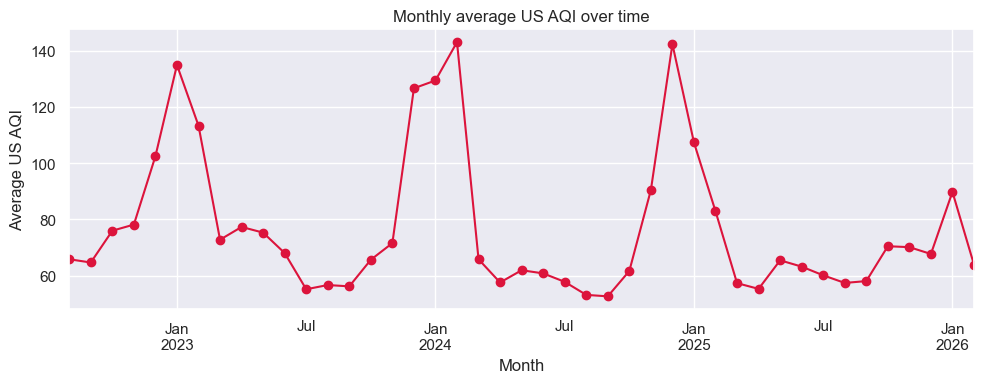

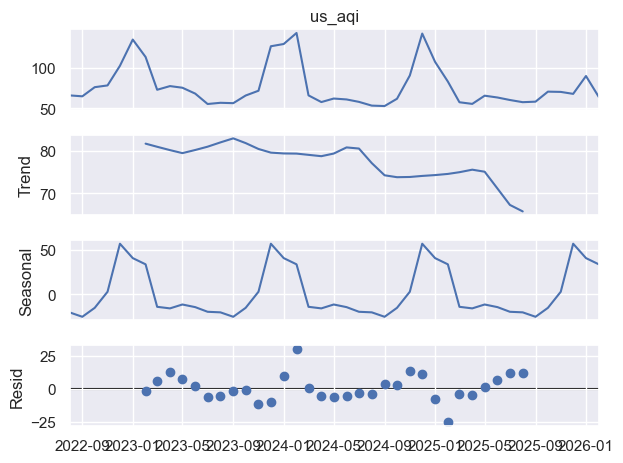

In [24]:
# Time series trend for AQI
from statsmodels.tsa.seasonal import seasonal_decompose
monthly = df.set_index('date').resample('MS')['us_aqi'].mean().dropna()
monthly.plot(figsize=(10, 4), marker='o', color='crimson')
plt.title('Monthly average US AQI over time')
plt.ylabel('Average US AQI')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

# Simple seasonal decomposition for AQI trend and seasonality
result = seasonal_decompose(monthly, model='additive', period=12)
result.plot()
plt.tight_layout()
plt.show()


In [ ]:
# Key stakeholder insights
print('Top AQI drivers (highest positive correlation with US AQI):')
print(correlation_with_aqi.head(5))
print('\nRegression coefficients (higher positive values indicate stronger positive association with AQI):')
print(regression_summary.head(5))
print('\nInterpretation:')
print('- Pollutants with strong positive correlation to AQI should be prioritized in mitigation planning.')
print('- The regression output highlights which variables most influence daily AQI and can guide targeted interventions.')
print('- The monthly AQI trend helps identify whether conditions are worsening or improving over time.')
